# PINN — 2D Helmholtz Equation

$$u_{xx} + u_{yy} + k^2 u = f(x,y), \quad (x,y) \in [-1,1]^2$$

**BC:** $u = 0$ on all four sides (Dirichlet)  

**Manufactured exact solution:**
$$u(x,y) = \sin(a_1 \pi x)\sin(a_2 \pi y)$$
$$f(x,y) = \bigl(k^2 - a_1^2\pi^2 - a_2^2\pi^2\bigr)\sin(a_1\pi x)\sin(a_2\pi y)$$

Static PDE (no time) — good showcase for Fourier Feature Embedding.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinns import PINN

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Problem Setup

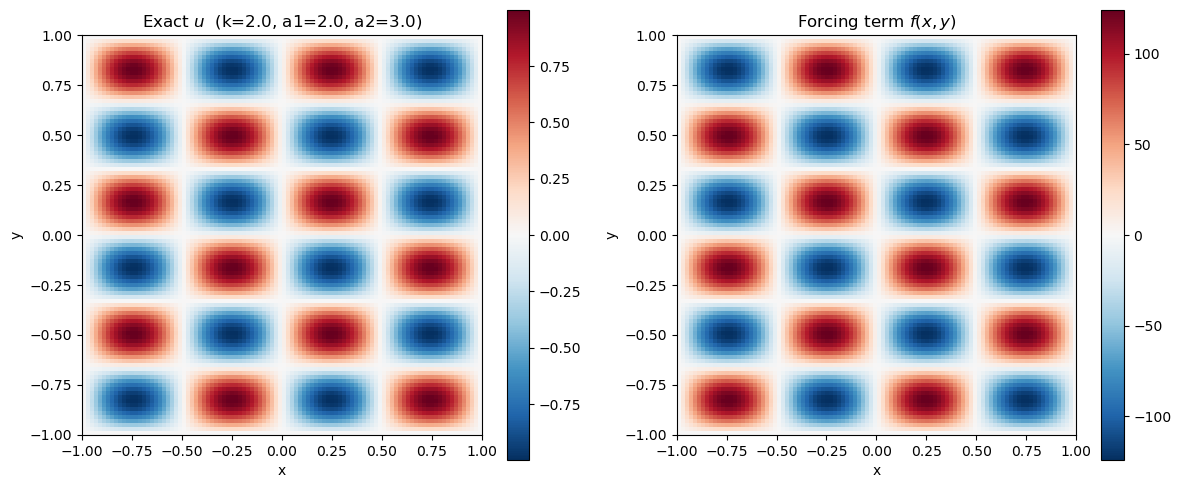

Forcing coefficient c = k²-(a1π)²-(a2π)² = -124.3049


In [3]:
k  = 2.0
a1 = 2.0
a2 = 3.0

def exact_u(x, y):
    return np.sin(a1 * np.pi * x) * np.sin(a2 * np.pi * y)

def forcing(x, y):
    c = k**2 - (a1 * np.pi)**2 - (a2 * np.pi)**2
    return c * np.sin(a1 * np.pi * x) * np.sin(a2 * np.pi * y)

# Visualise exact solution
x_demo = np.linspace(-1, 1, 100)
y_demo = np.linspace(-1, 1, 100)
XX, YY = np.meshgrid(x_demo, y_demo)
U_demo = exact_u(XX, YY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(U_demo, extent=[-1,1,-1,1], origin='lower', aspect='equal', cmap='RdBu_r')
axes[0].set_title(f'Exact $u$  (k={k}, a1={a1}, a2={a2})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); plt.colorbar(im0, ax=axes[0])

F_demo = forcing(XX, YY)
im1 = axes[1].imshow(F_demo, extent=[-1,1,-1,1], origin='lower', aspect='equal', cmap='RdBu_r')
axes[1].set_title('Forcing term $f(x,y)$')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); plt.colorbar(im1, ax=axes[1])

plt.tight_layout(); plt.show()
print(f'Forcing coefficient c = k²-(a1π)²-(a2π)² = {k**2-(a1*np.pi)**2-(a2*np.pi)**2:.4f}')

## Sampling

In [4]:
N_pde = 10000
N_bc  =  1000   # per side

# --- Interior collocation points (x, y) ---
xy_pde = torch.tensor(
    np.column_stack([np.random.uniform(-1, 1, N_pde),
                     np.random.uniform(-1, 1, N_pde)]),
    dtype=torch.float32).to(device)

# --- BC: u=0 on all four sides ---
s    = np.random.uniform(-1, 1, N_bc)
ones = np.ones(N_bc)

bc_left   = np.column_stack([-ones,  s])    # x=-1
bc_right  = np.column_stack([ ones,  s])    # x=+1
bc_bottom = np.column_stack([  s, -ones])   # y=-1
bc_top    = np.column_stack([  s,  ones])   # y=+1

xy_bc = torch.tensor(
    np.vstack([bc_left, bc_right, bc_bottom, bc_top]),
    dtype=torch.float32).to(device)

u_bc = torch.zeros(4 * N_bc, 1, dtype=torch.float32).to(device)   # homogeneous Dirichlet

print(f'PDE: {xy_pde.shape}  BC: {xy_bc.shape} / {u_bc.shape}')

PDE: torch.Size([10000, 2])  BC: torch.Size([4000, 2]) / torch.Size([4000, 1])


## PDE Residual

In [5]:
pi = np.pi

def pde_fn(model, xy):
    u      = model(xy)                                                             # [N,1]
    grads  = torch.autograd.grad(u, xy, torch.ones_like(u), create_graph=True)[0]
    u_x    = grads[:, 0:1]
    u_y    = grads[:, 1:2]
    u_xx   = torch.autograd.grad(u_x, xy, torch.ones_like(u_x),
                                  create_graph=True)[0][:, 0:1]
    u_yy   = torch.autograd.grad(u_y, xy, torch.ones_like(u_y),
                                  create_graph=True)[0][:, 1:2]
    c      = k**2 - (a1 * pi)**2 - (a2 * pi)**2
    f_vals = c * torch.sin(a1 * pi * xy[:, 0:1]) * torch.sin(a2 * pi * xy[:, 1:2])
    return u_xx + u_yy + k**2 * u - f_vals


## Model & Training

In [6]:
import os; os.makedirs('./checkpoints', exist_ok=True)

model = PINN(
    layers=[2, 128, 128, 128, 128, 1],
    activation='tanh',
    skip=True
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 99,585


In [7]:
# Helmholtz is static (no time), so no IC is needed
model.fit(
    pde_fn=pde_fn,
    x_pde=xy_pde, x_bc=xy_bc, u_bc=u_bc,
    # x_ic=None  (no initial condition)
    epochs=20000, lr=1e-3,
    w_pde=1.0, w_bc=10.0,
    log_every=500,
    save_path='./checkpoints/best_helmholtz.pt',
)

c:\Users\teamlee4\anaconda3\envs\cuda\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[     1/20000]  Total: 3.873e+03  PDE: 3.872e+03  BC: 3.780e-02
[   500/20000]  Total: 3.946e+00  PDE: 2.833e+00  BC: 1.113e-01
[  1000/20000]  Total: 7.624e-01  PDE: 4.805e-01  BC: 2.819e-02
[  1500/20000]  Total: 2.907e-01  PDE: 1.620e-01  BC: 1.288e-02
[  2000/20000]  Total: 2.290e-01  PDE: 1.440e-01  BC: 8.505e-03
[  2500/20000]  Total: 2.690e-01  PDE: 2.055e-01  BC: 6.353e-03
[  3000/20000]  Total: 1.709e-01  PDE: 1.081e-01  BC: 6.278e-03
[  3500/20000]  Total: 1.136e-01  PDE: 6.758e-02  BC: 4.603e-03
[  4000/20000]  Total: 1.205e-01  PDE: 8.261e-02  BC: 3.792e-03
[  4500/20000]  Total: 7.374e-02  PDE: 4.169e-02  BC: 3.205e-03
[  5000/20000]  Total: 2.857e+00  PDE: 2.566e+00  BC: 2.907e-02
[  5500/20000]  Total: 1.474e+00  PDE: 1.385e+00  BC: 8.881e-03
[  6000/20000]  Total: 9.843e-02  PDE: 7.461e-02  BC: 2.383e-03
[  6500/20000]  Total: 3.570e-01  PDE: 3.254e-01  BC: 3.166e-03
[  7000/20000]  Total: 1.480e-01  PDE: 1.240e-01  BC: 2.395e-03
[  7500/20000]  Total: 9.554e-02  PDE: 7

## Loss History

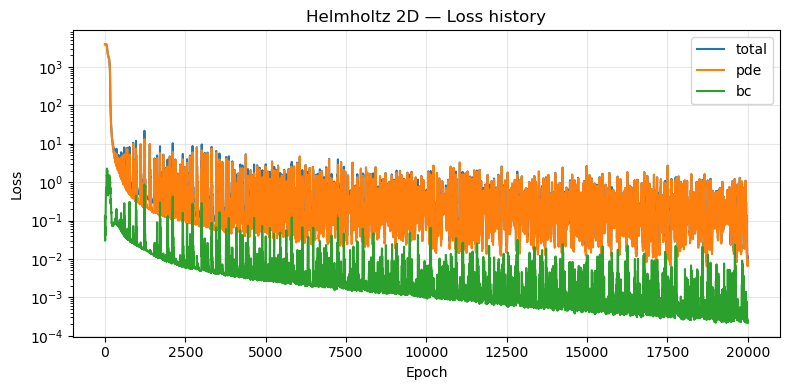

In [8]:
ep  = range(1, len(model.loss_history['total']) + 1)
fig, ax = plt.subplots(figsize=(8, 4))
for key in ['total', 'pde', 'bc']:
    ax.semilogy(ep, model.loss_history[key], label=key)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
ax.set_title('Helmholtz 2D — Loss history'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Prediction vs Exact Solution

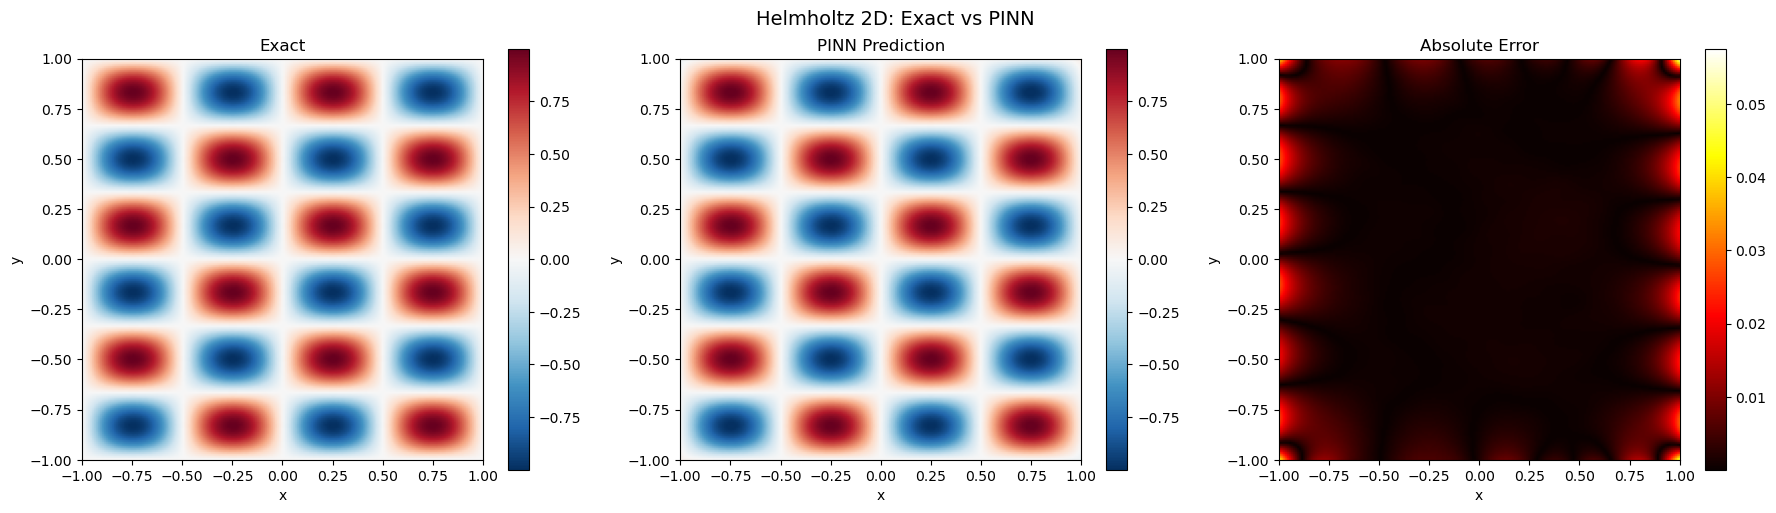

Relative L2 error: 0.0101  (1.01%)


In [9]:
N_vis = 200
x_v   = np.linspace(-1, 1, N_vis)
y_v   = np.linspace(-1, 1, N_vis)
XX, YY = np.meshgrid(x_v, y_v)

xy_vis = torch.tensor(np.column_stack([XX.ravel(), YY.ravel()]),
                       dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    U_pred = model(xy_vis).cpu().numpy().reshape(N_vis, N_vis)

U_exact = exact_u(XX, YY)
U_err   = np.abs(U_pred - U_exact)
vmax    = np.abs(U_exact).max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [-1, 1, -1, 1]

im0 = axes[0].imshow(U_exact, extent=ext, origin='lower', aspect='equal',
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('Exact'); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_pred, extent=ext, origin='lower', aspect='equal',
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('PINN Prediction'); plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(U_err, extent=ext, origin='lower', aspect='equal', cmap='hot')
axes[2].set_title('Absolute Error'); plt.colorbar(im2, ax=axes[2])

for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('Helmholtz 2D: Exact vs PINN', fontsize=14)
plt.tight_layout(); plt.show()

rel_l2 = np.linalg.norm(U_pred - U_exact) / np.linalg.norm(U_exact)
print(f'Relative L2 error: {rel_l2:.4f}  ({rel_l2*100:.2f}%)')

## Cross-sections

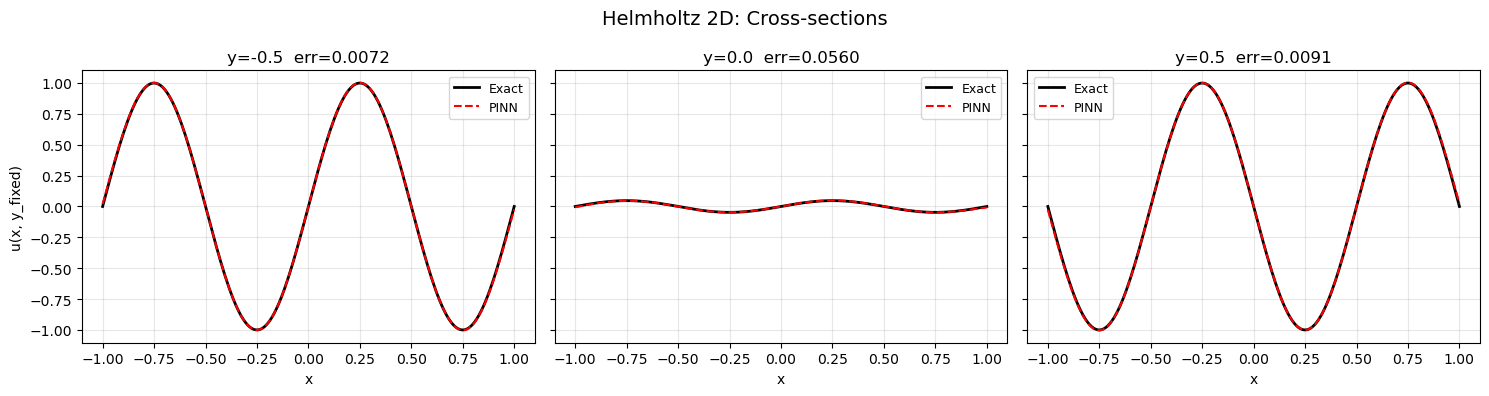

In [10]:
# Cross-section at y = 0.5
y_fixed_vals = [-0.5, 0.0, 0.5]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, y_fixed in zip(axes, y_fixed_vals):
    iy = np.argmin(np.abs(y_v - y_fixed))
    u_ex  = U_exact[iy]
    u_pr  = U_pred[iy]
    err   = np.linalg.norm(u_pr - u_ex) / (np.linalg.norm(u_ex) + 1e-10)
    ax.plot(x_v, u_ex,  'k-',  lw=2,   label='Exact')
    ax.plot(x_v, u_pr,  'r--', lw=1.5, label='PINN')
    ax.set_title(f'y={y_fixed:.1f}  err={err:.4f}')
    ax.set_xlabel('x'); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

axes[0].set_ylabel('u(x, y_fixed)')
plt.suptitle('Helmholtz 2D: Cross-sections', fontsize=14)
plt.tight_layout(); plt.show()